# Problem Set 2 - Mixing Laws and Physical Property Estimation
## Student Name: (Enter your name here)

In this Jupyter Notebook, you will explore mixing relations and estimating physical properties from geochemistry using empirical relations, i.e., relations that are mathematically (not physically) based.  There are several places for you to include written answers as well.  Please utilize these as necessary to comment on results.

### Problem 1 - Mixing Relations

In this problem, you will explore the relationship between the three mixing laws: arithmetic, geometric and harmonic.

#### A. Derivation
Either return your answer as a paper scan or type the solution below in LaTeX.

Space for Answer to A.

#### B. Distributions

Much of this example is worked for you.  You only need to answer the question at the end.  What is calculated below and displayed in the figure are three distributions.  Each are a random distribution with arithmetic mean of 3 and standard deviation of 0.5.  To compute the distributions for the geometric and harmonic case, they are computed as normal distributions in their native space and then displayed in linear space so you can see what a distribution of data may look like that can be used to predict the correct mixing law.

In [1]:
import sys
print(sys.executable)

# --- Problem 1B: distributions in arithmetic/log/reciprocal space
import numpy as np
import matplotlib.pyplot as plt

%load_ext ipympl
%matplotlib widget

/Users/dhasterok/Library/CloudStorage/GoogleDrive-dhasterok@gmail.com/My Drive/classes/GeophysicsIIIA/new_version/.venv/bin/python
The ipympl module is not an IPython extension.


2.9591817714964317 1.0849128015740526 0.16552635496534787
2.9189189189189193 0.34259259259259256 0.05555555555555555


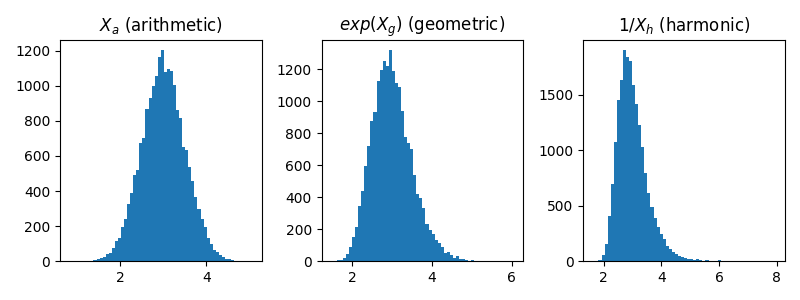

In [2]:
rng = np.random.default_rng(42)
N = 20_000
# Arithmetic in each space
mu_a, sigma_a = 3.0, 0.5           # positive normal (most samples > 0)
X_a = rng.normal(mu_a, sigma_a, N)
X_a = X_a[X_a > 0]                    # drop rare negatives (or set mu/sigma to avoid negatives)

sigma_g = np.sqrt(np.log((sigma_a / mu_a)**2 + 1.0))
mu_g = np.log(mu_a) - sigma_g**2 / 2.0
X_g = rng.normal(mu_g, sigma_g, N)
print(np.exp(mu_g), mu_g, sigma_g)

mu_h = 1.0 / mu_a + sigma_a**2 / mu_a**3
sigma_h =  sigma_a / mu_a**2
X_h = rng.normal(mu_h, sigma_h, N)
print(1.0/mu_h, mu_h, sigma_h)


fig, axs = plt.subplots(1, 3, figsize=(8,3))
axs[0].hist(X_a, bins=60); axs[0].set_title("$X_a$ (arithmetic)")
axs[1].hist(np.exp(X_g), bins=60); axs[1].set_title("$exp(X_g)$ (geometric)")
axs[2].hist(1.0/X_h, bins=60); axs[2].set_title("$1/X_h$ (harmonic)")
plt.tight_layout()


#### Question:

#### Describe the differences between the center and right distributions and how they differ from the normal distribution on the left.  What are their distinguishing characteristics if any?

(Enter your answer here)

### Problem 2 - Empirical Property Estimates

To simplify the process, some of the coding has been done for you.

In [3]:
# --- Problem 2: chemistry -> properties (Jupyter)
import pandas as pd

# ---------- Configuration ----------
DATA_PATH = "rock_chem.xlsx"   # <- students: point this to your CSV

# ---------- Load ----------
df = pd.read_excel(DATA_PATH)

#### Quick Pandas Primer

We'll be using the python library pandas (pd) to interogate, filter, compute a new column and summarize and plot the results.  Pandas is a handy library that allows us to import tabular data from a csv or Excel spreadsheet and do all the aforementioned operations.  So let's have a quick primer on how to use pandas.  To start, we'll look at the first few rows.

In [4]:
df.head()

,rock_type,sio2,tio2,al2o3,feo_tot,mgo,cao,k2o,na2o,p2o5,u_ppm,th_ppm
0,granite,74.775342,0.110407,13.951373,1.065698,0.291072,1.385100,4.546742,3.834118,0.040148,1.4,23.0
1,granite,74.041566,0.221320,13.782194,1.774206,0.573420,2.022059,3.702078,3.802678,0.080480,0.5,8.0
2,granite,71.151396,0.272495,15.239519,2.406524,0.544989,1.957925,4.137883,4.188345,0.100924,0.6,12.0
3,granite,75.615814,0.162179,12.670210,1.851484,0.304085,1.114978,5.118765,3.111804,0.050681,1.5,34.0
4,granite,70.889477,0.342364,15.305682,2.265162,0.735076,2.114601,3.826421,4.420523,0.100695,1.4,28.0


Look at the column names.

In [5]:
df.columns # column names are case-sensitive, so check this carefully!

Index(['rock_type', 'sio2', 'tio2', 'al2o3', 'feo_tot', 'mgo', 'cao', 'k2o',
       'na2o', 'p2o5', 'u_ppm', 'th_ppm'],
      dtype='str')

In [6]:
# unique rock types
df.rock_type.unique()

<StringArray>
[          'granite',           'diorite',      'granodiorite',
  'gabbroic diorite',    'alkalic gabbro', 'subalkalic gabbro',
         'monzonite',      'monzodiorite',           'syenite',
 'mantle peridotite',       'monzogabbro', 'mantle pyroxenite']
Length: 12, dtype: str

Extract columns, rows, or filter the data.

In [7]:
sio2 = df["sio2"] # Return a series.
sio2 = df.sio2 # Same as above, but more concise. Note: no parentheses since it's not a function.

Extract multiple columns.

In [8]:
major_elements = df[["sio2", "feo_tot", "mgo"]] # Filter a dataframe for selected columns, returning a DataFrame.

Drop a column

In [9]:
#df = df.drop(columns=["Density"])

Filtering

Example: Create a Mg\# (molar proxy version), where $$Mg\# = \frac{MgO}{MgO + FeO}$$

In [10]:
df["Mg_number"] = df["mgo"] / (df["mgo"] + df["feo_tot"])
df.head() # see the new column Mg_number

,rock_type,sio2,tio2,al2o3,feo_tot,mgo,cao,k2o,na2o,p2o5,u_ppm,th_ppm,Mg_number
0,granite,74.775342,0.110407,13.951373,1.065698,0.291072,1.385100,4.546742,3.834118,0.040148,1.4,23.0,0.214533
1,granite,74.041566,0.221320,13.782194,1.774206,0.573420,2.022059,3.702078,3.802678,0.080480,0.5,8.0,0.244255
2,granite,71.151396,0.272495,15.239519,2.406524,0.544989,1.957925,4.137883,4.188345,0.100924,0.6,12.0,0.184647
3,granite,75.615814,0.162179,12.670210,1.851484,0.304085,1.114978,5.118765,3.111804,0.050681,1.5,34.0,0.141070
4,granite,70.889477,0.342364,15.305682,2.265162,0.735076,2.114601,3.826421,4.420523,0.100695,1.4,28.0,0.245006


In [11]:
high_silica = df[df["sio2"] > 60] # filter rows by a single condition
filtered = df[(df["sio2"] > 60) & (df["mgo"] < 5)] # filter rows by multiple conditions (AND = &, OR = |, NOT = ~)

Summary Statistics

In [12]:
df.describe()   # summarize all columns


,sio2,tio2,al2o3,feo_tot,mgo,cao,k2o,na2o,p2o5,u_ppm,th_ppm,Mg_number
count,126611.000000,126611.000000,126611.000000,126611.000000,126611.000000,126611.000000,126611.000000,126611.000000,126611.000000,73049.000000,83644.000000,126608.000000
mean,63.909660,0.720453,15.138299,5.181178,3.955985,4.657739,2.835179,3.411407,0.188801,3.909319,13.644307,0.316039
std,10.033873,0.770906,3.349782,3.995644,7.484800,3.790865,1.938250,1.273361,0.226967,64.806292,35.359380,0.170126
min,33.453444,-0.050337,0.000000,0.000000,-0.500200,-0.100120,-0.020831,-0.150060,-5.020039,-50.000000,-93.000000,-3.850124
25%,54.528234,0.253293,13.916247,1.942426,0.518294,1.503363,1.161011,2.765060,0.062064,0.593598,2.200000,0.207183
50%,66.222567,0.512945,15.246504,3.984890,1.701805,3.500380,2.699411,3.472068,0.131850,1.800000,7.730000,0.298134
75%,72.736323,0.924552,16.775238,7.744618,4.700105,7.286887,4.392700,4.119816,0.232969,4.000000,18.000000,0.396552
max,86.715018,18.970448,39.267566,41.209158,53.258133,40.683159,15.315996,12.002400,9.142560,13600.000000,7000.000000,3.333333


In [13]:
df[["sio2", "mgo", "feo_tot"]].describe()  # summarize specific columns


,sio2,mgo,feo_tot
count,126611.000000,126611.000000,126611.000000
mean,63.909660,3.955985,5.181178
std,10.033873,7.484800,3.995644
min,33.453444,-0.500200,0.000000
25%,54.528234,0.518294,1.942426
50%,66.222567,1.701805,3.984890
75%,72.736323,4.700105,7.744618
max,86.715018,53.258133,41.209158


In [14]:
df[df["sio2"] > 60]["mgo"].mean() # filter rows by a condition, then summarize a column


np.float64(1.1102598999398527)

In [15]:
df[df["sio2"] > 60][["sio2", "mgo", "feo_tot"]].describe()  # filter rows by a condition, then summarize specific columns

,sio2,mgo,feo_tot
count,80946.000000,80946.000000,80946.000000
mean,70.558723,1.110260,2.820033
std,4.894150,1.077353,1.825052
min,60.000159,-0.500200,0.000000
25%,67.060666,0.324981,1.447276
50%,71.468217,0.728460,2.403473
75%,74.299860,1.612522,3.887734
max,86.715018,16.053440,22.523947


Useful extras:

In [16]:
df.sort_values("sio2", ascending=False)
df.head()

# export the modified DataFrame to a new Excel file
df.to_excel("modified_data.xlsx", index=False)

# ---------- Data cleaning ----------
clean_cols = [c for c in df.columns if c != 'rock_type']
df[clean_cols] = df[clean_cols].mask(df[clean_cols] < 0)

#### Main Property Code
You will need to complete the calculations as discussed in the problem set handout.

In [17]:
import math
from MolecularWeightCalculator import MolecularWeightCalculator

mwc = MolecularWeightCalculator()

# Density (kg/m^3)
oxlist = ['sio2', 'tio2', 'al2o3', 'feo_tot', 'mgo', 'cao', 'na2o', 'k2o', 'p2o5']
tmp_df = df[oxlist].astype(float)
total_oxides = df[oxlist].sum(axis=1)
tmp_df = 100 * tmp_df.div(total_oxides, axis=0)  # convert to wt% if not already

# convert to molar proportions
# Use mwc.molecular_weight('') to get the molecular weight of an oxide, e.g. mwc.molecular_weight('SiO2')
n_tio2 = ###
n_feo = ###
n_mgo = ###

# compute parameters neeeded for the empirical density model
fe_number = ###
MALI = ###
maficity = ###

# compute density
df["RHO"] = ###

# prep for velocity calculations
oxlist = ['sio2', 'al2o3', 'feo_tot', 'mgo', 'cao', 'na2o', 'k2o']
### create a temporary DataFrame with the oxides, convert to wt% if not already, and convert to molar proportions as needed for the thermal conductivity model

# Vp P-wave Seismic Velocity (km/s)
df["Vp"] = ### Enter your formula here

# Vs P-wave Seismic Velocity (km/s)
df["Vs"] = ### Enter your formula here

# prep for thermal conductivity calculations
oxlist = ['sio2', 'tio2', 'al2o3', 'feo_tot', 'mgo', 'cao', 'na2o', 'k2o']
### create a temporary DataFrame with the oxides, convert to wt% if not already, and convert to molar proportions as needed for the thermal conductivity model

# Thermal Conductivity (W/m/K)
df["TC"] = ### Enter your formula here

# ---------- Chemistry helpers ----------
# Convert K2O wt% -> elemental K wt%
K = 1.0e4 * (2*mwc.molecular_weight('K')/mwc.molecular_weight('K2O')) * df["k2o"]

# Radiogenic heat production  A (μW/m^3):
# A ≈ ρ * (0.0952*U_ppm + 0.0256*Th_ppm + 0.00348*K_wt%)
df["HP"] = df.RHO * (98.29*df.u_ppm + 26.18*df.th_ppm + 0.003387*K)*1.0e-6  # convert to μW/m^3

SyntaxError: invalid syntax (3868753660.py, line 14)

#### Summary Table Output

If you've done everything correctly below, the table should generate without error.  Note that a file of outputs is produced.  You can use this as a reference for values of common rock properties... in most cases.

In [ ]:
# ---------- Group summaries ----------
def sig3(x):
    if pd.isna(x):
        return "—"
    if x == 0:
        return "0"
    mag = math.floor(math.log10(abs(x)))
    decimals = max(0, 2 - mag)
    return f"{round(x, -mag + 2):.{decimals}f}"

props = ["RHO", "Vp", "Vs", "TC", "HP"]                      # add more here when available
rock_order = ["granite", "granodiorite", "diorite", "gabbroic diorite", "subalkalic gabbro", "syenite", "monzonite", "monzodiorite", "monzogabbro", "alkalic gabbro", "mantle peridotite", "mantle pyroxenite"]
df["rock_type"] = pd.Categorical(df["rock_type"], categories=rock_order, ordered=True)
stats = (df.groupby("rock_type")
           .agg(**{f"{p}_mean": (p, "mean") for p in props}
                | {f"{p}_std": (p, "std") for p in props}
                | {"SiO2_mean": ("sio2", "mean")})
           .reset_index())

summary = stats[["rock_type"]].copy()
for p in props:
    summary[p] = (stats[f"{p}_mean"].map(sig3)
          + " ± "
          + stats[f"{p}_std"].map(sig3))

# Save a wide summary table for each rock_type
out_summary = "property_summary_by_rocktype.csv"
summary.to_csv(out_summary, index=False)
print(f"Saved summary: {out_summary}")
summary

#### Visual Display of Geophysical Properties

The code below will produce a plot for each of the physical properties calculated in this notebook.  There is one last question to answer at the end.

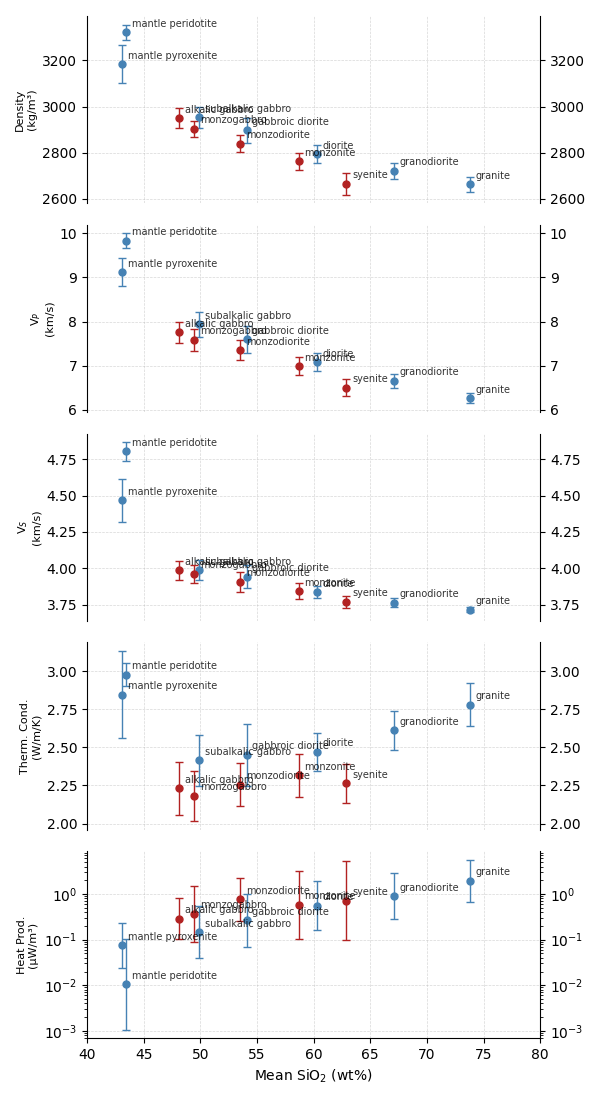

In [ ]:
props_to_plot = ["RHO", "Vp", "Vs", "TC", "HP"]  # extend as needed
prop_labels = {
    "RHO": "Density\n(kg/m³)",
    "Vp":  "V$_P$\n(km/s)",
    "Vs":  "V$_S$\n(km/s)",
    "TC":  "Therm. Cond.\n(W/m/K)",
    "HP":  "Heat Prod.\n(µW/m³)",
}

highlight = {'alkalic gabbro', 'monzogabbro', 'monzodiorite', 'monzonite', 'syenite'}
is_highlight = stats['rock_type'].isin(highlight).values

color_normal    = 'steelblue'
color_highlight = 'firebrick'

n = len(props_to_plot)
fig, axes = plt.subplots(n, 1, figsize=(6, 2.2*n), sharex=True)

for ax, prop in zip(axes, props_to_plot):
    x    = stats["SiO2_mean"].values
    y    = stats[f"{prop}_mean"].values
    yerr = stats[f"{prop}_std"].values

    if prop == 'HP':
        ax.set_yscale('log')
        sigma_ln    = np.sqrt(np.log(1 + (yerr / y)**2))
        mu_ln       = np.log(y) - sigma_ln**2 / 2
        mu_log10    = mu_ln / np.log(10)
        sigma_log10 = sigma_ln / np.log(10)
        y_plot      = 10**mu_log10
        err_factor  = 10**sigma_log10          # same factor up and down
        lo = y_plot * (1 - 1/err_factor)
        hi = y_plot * (err_factor - 1)
    else:
        y_plot = y
        lo = yerr
        hi = yerr

    #ax.errorbar(x, y, yerr=yerr_plot, fmt='o', color='steelblue',
    #            ecolor='steelblue', elinewidth=1, capsize=3,
    #            markersize=5, linewidth=1.2)
    
    for mask, color in [(~is_highlight, color_normal), (is_highlight, color_highlight)]:
        ax.errorbar(x[mask], y_plot[mask],
                    yerr=[lo[mask], hi[mask]],
                    fmt='o', color=color, ecolor=color,
                    elinewidth=1, capsize=3, markersize=5, zorder=2)
    
    ax.tick_params(axis='y', which='both', left=True, right=True,
               labelleft=True, labelright=True)

    ax.set_ylabel(prop_labels.get(prop, prop), fontsize=8)
    ax.set_xlim(40, 80)
    
    # rock type annotations
    #for _, r in stats.iterrows():
    #    ax.annotate(r["rock_type"],
    #                (r["SiO2_mean"], r[f"{prop}_mean"]),
    #                textcoords="offset points", xytext=(4, 4),
    #                fontsize=7, alpha=0.8)

    for xi, yi, name in zip(x, y_plot, stats['rock_type'].values):
        ax.annotate(name, (xi, yi),
                textcoords="offset points", xytext=(4, 4),
                fontsize=7, alpha=0.8)

for i, (ax, prop) in enumerate(zip(axes, props_to_plot)):
    # ... existing errorbar and ylabel code ...

    ax.grid(True, which='major', axis='both', linestyle='--', linewidth=0.5, alpha=0.5)

    ax.spines['top'].set_visible(False)

    if i < n - 1:                                  # all but bottom
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(axis='x', bottom=False, labelbottom=False)


axes[-1].set_xlabel("Mean SiO$_2$ (wt%)")
fig.tight_layout()
plt.show()

#### Questions:

In geology, the amount of SiO$_2$ in a rock is useful parameter for dividing rocks because in addition to the major axis of compositional differences it also provides the greatest spread in physical properties.  We refer to the amount of SiO$_2$ as how felsic (high SiO$_2$) or mafic (low SiO$_2$) a sample is.  This is often visually apparent in the samples and a good way to generalize the properties of a rock as well.

##### What sort of relationship is common among most properties (except for heat production)?

(Enter your answer here)

##### What is the relationship for heat production and why is heat production different?

(Enter your answer here)

Alkalinity is defined as the amount of Na$_2$O and K$_2$O in a rock and typically defines the second major axis of chemical differences.  The rocks in blue above are among the most common rock types in the crust, defining a subalkaline chemical trend.  The red rocks are less common, though not uncommon in all settings.  These rocks are define a more alkaline trend.

##### How does the alkalinity affect the physical properties?

(Enter your answer here)